In [2]:
# import library
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [15]:
# Initialize quantization matrix
QUANTIZATION_MAT =  np.array([[17, 18, 24, 47, 99, 99, 99, 99],  # chrominance quantization table
                [18, 21, 26, 66, 99, 99, 99, 99],
                [24, 26, 56, 99, 99, 99, 99, 99],
                [47, 66, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99]])

In [ ]:
# define all function

# Function define grayscale image
def get_grayscale_image(image_name):
    image = cv2.imread(image_name)
    image = cv2.resize(image, (256, 256))
    R = image[:, :, 0]
    G = image[:, :, 1]
    B = image[:, :, 2]
    Y = 0.299 * R + 0.587 * G + 0.114 * B
    return Y

def divide_into_blocks(image_array, block_size=8):
    height, width = image_array.shape
    blocks = []
    for i in range(0, height, block_size):
        for j in range(0, width, block_size):
            block = image_array[i:i + block_size, j:j + block_size]
            blocks.append(block)
    return np.array(blocks)

# Calculate 2D-DCT II Formula
def get_2d_dct(block):
    N = block.shape[0]
    F = np.zeros_like(block)

    for u in tqdm(range(N), desc="dct2d_process"):
        for v in range(N):
            C_u = 1 / np.sqrt(2) if u == 0 else 1
            C_v = 1 / np.sqrt(2) if v == 0 else 1

            sum = 0.0
            for x in range(N):
                for y in range(N):
                    sum += (
                        block[x, y]
                        * np.cos((2 * x + 1) * np.pi * u / (2 * N))
                        * np.cos((2 * y + 1) * np.pi * v / (2 * N))
                    )

            F[u, v] = sum * C_u * C_v * (2 / N)
    return F

# Calulate 2D-IDCT
def get_2d_idct(coe_block):
    N = coe_block.shape[0]
    F_reconstructed = np.zeros_like(coe_block)

    for x in tqdm(range(N), desc="idct2d_process"):
        for y in range(N):
            sum = 0.0
            for u in range(N):
                for v in range(N):
                    C_u = 1 / np.sqrt(2) if u == 0 else 1
                    C_v = 1 / np.sqrt(2) if v == 0 else 1

                    sum += (
                        C_u
                        * C_v
                        * coe_block[u, v]
                        * np.cos((2 * x + 1) * u * np.pi / (2 * N))
                        * np.cos((2 * y + 1) * v * np.pi / (2 * N))
                    )

            F_reconstructed[x, y] = sum * (2 / N)
    return F_reconstructed

# Calculate PSNR
def get_psnr(expect, actual):
    mse = np.mean((expect - actual) ** 2)
    if mse == 0:
        return 100
    # Grayscale image with 8 bit
    print(f"MSE = {mse}")
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel * max_pixel) / mse)
    return psnr

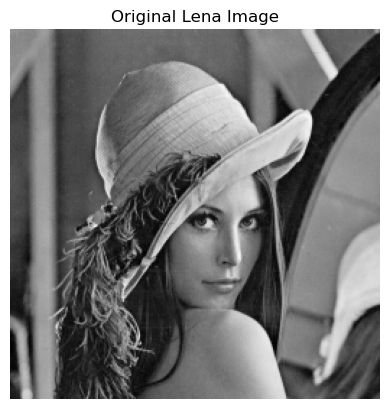

The shape of image is: (256, 256)


In [10]:
# Load image grey scale
image = get_grayscale_image("lena.png")

# Display the original image
plt.imshow(image, cmap="gray")
plt.title("Original Lena Image")
plt.axis("off")
plt.show()

# Show the image matrix shape
print(f"The shape of image is: {image.shape}")

In [14]:
# Divide the image into 8x8 blocks
blocks = divide_into_blocks(image)

# Show the number of blocks and the shape of each block - NO overlap
blocks.shape

(1024, 8, 8)

In [ ]:
# Compute the 2D DCT of each block
for i in range(len(blocks)):
    blocks[i, :, :] = get_2d_dct(blocks[i, :, :])

dct2d_process: 100%|██████████| 8/8 [00:00<00:00, 797.19it/s]

(1024, 8, 8)


In [26]:
# Quantize the DCT coefficients with two quantization tables
quantization_table_1 = np.array([
    [10, 7, 6, 10, 14, 24, 31, 37],
    [7, 7, 8, 11, 16, 35, 36, 33],
    [8, 8, 10, 14, 24, 34, 41, 34],
    [8, 10, 13, 17, 31, 52, 48, 37],
    [11, 13, 22, 34, 41, 65, 62, 46],
    [14, 21, 33, 38, 49, 62, 68, 55],
    [29, 38, 47, 52, 62, 73, 72, 61],
    [43, 55, 57, 59, 67, 60, 62, 59]
])

quantization_table_2 = np.array([
    [10, 11, 14, 28, 59, 59, 59, 59],
    [11, 13, 16, 40, 59, 59, 59, 59],
    [14, 16, 34, 59, 59, 59, 59, 59],
    [28, 40, 59, 59, 59, 59, 59, 59],
    [59, 59, 59, 59, 59, 59, 59, 59],
    [59, 59, 59, 59, 59, 59, 59, 59],
    [59, 59, 59, 59, 59, 59, 59, 59],
    [59, 59, 59, 59, 59, 59, 59, 59]
])

def quantize_block(dct_block, quant_table):
    return np.round(dct_block / quant_table).astype(int)

quantized_blocks_1 = np.array([quantize_block(block, quantization_table_1) for block in blocks])
quantized_blocks_2 = np.array([quantize_block(block, quantization_table_2) for block in blocks])

In [31]:
# Run-Length Encoding using zigzag scan
zigzag_indices = np.array([
    [0, 1, 5, 6, 14, 15, 27, 28],
    [2, 4, 7, 13, 16, 26, 29, 42],
    [3, 8, 12, 17, 25, 30, 41, 43],
    [9, 11, 18, 24, 31, 40, 44, 53],
    [10, 19, 23, 32, 39, 45, 52, 54],
    [20, 22, 33, 38, 46, 51, 55, 60],
    [21, 34, 37, 47, 50, 56, 59, 61],
    [35, 36, 48, 49, 57, 58, 62, 63]
]).flatten()

def zigzag_scan(block):
    return block.flatten()[zigzag_indices]

def run_length_encode(arr):
    encoded = []
    last_val = arr[0]
    count = 1
    for val in arr[1:]:
        if val == last_val:
            count+=1
        else:
            encoded.append((count, last_val))
            last_val = val
            count = 1
    encoded.append((count, last_val))
    return encoded

encoded_blocks_1 = [run_length_encode(zigzag_scan(block)) for block in quantized_blocks_1]
encoded_blocks_2 = [run_length_encode(zigzag_scan(block)) for block in quantized_blocks_2]


In [32]:
# Run-length decoding and inverse zigzag scan

def run_length_decode(encoded):
    decoded = []
    for count, value in encoded:
        decoded.extend([value] * count)
    return np.array(decoded)

def inverse_zigzag_scan(arr, block_size = 8):
    block = np.zeros((block_size, block_size), dtype=int)
    for i,index in enumerate(zigzag_indices):
        block[index // block_size, index % block_size] = arr[i]
    return block

# Decode and reconstruct quantized blocks for both tables
decoded_blocks_1 = [inverse_zigzag_scan(run_length_decode(encoded)) for encoded in encoded_blocks_1]
decoded_blocks_2 = [inverse_zigzag_scan(run_length_decode(encoded)) for encoded in encoded_blocks_2]

In [33]:
# inverse quantization function
def inverse_quantize_block(block, quant_table):
    return (block * quant_table).astype(float)

inverse_quantized_blocks_1 = [inverse_quantize_block(block, quantization_table_1) for block in decoded_blocks_1]
inverse_quantized_blocks_2 = [inverse_quantize_block(block, quantization_table_2) for block in decoded_blocks_2]

In [40]:
# apply 2d idct to each block
reconstructed_block_1 = [get_2d_idct(block) for block in inverse_quantized_blocks_1]
reconstructed_block_2 = [get_2d_idct(block) for block in inverse_quantized_blocks_2]

idct2d_process: 100%|██████████| 8/8 [00:00<00:00, 312.75it/s]


In [41]:
# Recombine 8x8 blocks into a full image
def recombine_blocks(blocks, image_shape, block_size=8):
    h, w = image_shape
    reconstructed_image = np.zeros((h, w), dtype=np.float32)
    index = 0
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            reconstructed_image[i:i+block_size, j:j+block_size] = blocks[index]
            index += 1
    return np.clip(reconstructed_image, 0, 255).astype(np.uint8)

# Reconstruct images for both quantization tables
reconstructed_image_1 = recombine_blocks(reconstructed_block_1, image.shape)
reconstructed_image_2 = recombine_blocks(reconstructed_block_2, image.shape)

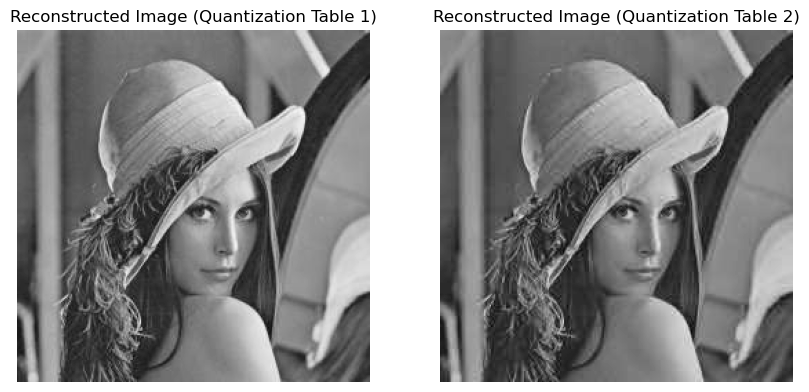

In [42]:
# Display reconstructed images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(reconstructed_image_1, cmap='gray')
plt.title("Reconstructed Image (Quantization Table 1)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image_2, cmap='gray')
plt.title("Reconstructed Image (Quantization Table 2)")
plt.axis("off")
plt.show()

In [45]:
# Calculate total size of encoded data (number of run-length pairs) for each quantization table
total_size_encoded_1 = sum(len(encoded) for encoded in encoded_blocks_1)
total_size_encoded_2 = sum(len(encoded) for encoded in encoded_blocks_2)

print("Total encoded size (Quantization Table 1):", total_size_encoded_1)
print("Total encoded size (Quantization Table 2):", total_size_encoded_2)

total_size = sum(len(block) for block in blocks)
print("Total actual size:", total_size)

Total encoded size (Quantization Table 1): 18697
Total encoded size (Quantization Table 2): 12125
Total actual size: 8192


In [44]:
# PSNR
print(f"PSNR of quantization table 1: {get_psnr(image, reconstructed_image_1)}")
print(f"PSNR of quantization table 2: {get_psnr(image, reconstructed_image_2)}")

MSE = 18.652289568283074
PSNR of quantization table 1: 35.42348211809491
MSE = 38.92051927409362
PSNR of quantization table 2: 32.22901734914735
